#  Hybrid CLV
### BG/NBD + Gamma-Gamma + XGBoost + SHAP + Segmentation + Visuals
This notebook leverages statistical modeling and machine learning to accurately predict **Customer Lifetime Value (CLV)** using:
-  BG/NBD & Gamma-Gamma probabilistic modeling
-  XGBoost with engineered features
-  10 Hypotheses visualized
-  SHAP for interpretability
-  Feature bucketing & hyperparameter tuning
-  Segmentation of customers into CLV tiers

##  Imports

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from lifetimes import BetaGeoFitter, GammaGammaFitter
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error
import shap
import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')


##  Load and Inspect Dataset

In [61]:
df = pd.read_csv('file.csv')
df = df[df['CustomerID'].notnull()]
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], errors='coerce')
df['CustomerID'] = df['CustomerID'].astype(int)
df.dropna(subset=['Transaction_Date'], inplace=True)
df['TotalPrice'] = df['Quantity'] * df['Avg_Price']
df = df[df['TotalPrice'] > 0]
df.head()


,Unnamed: 0,CustomerID,Gender,Location,Tenure_Months,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,...,Delivery_Charges,Coupon_Status,GST,Date,Offline_Spend,Online_Spend,Month,Coupon_Code,Discount_pct,TotalPrice
0,0,17850,M,Chicago,12.0,16679.0,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,...,6.5,Used,0.1,1/1/2019,4500.0,2424.5,1,ELEC10,10.0,153.71
1,1,17850,M,Chicago,12.0,16680.0,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,...,6.5,Used,0.1,1/1/2019,4500.0,2424.5,1,ELEC10,10.0,153.71
2,2,17850,M,Chicago,12.0,16696.0,2019-01-01,GGOENEBQ078999,Nest Cam Outdoor Security Camera - USA,Nest-USA,...,6.5,Not Used,0.1,1/1/2019,4500.0,2424.5,1,ELEC10,10.0,245.54
3,3,17850,M,Chicago,12.0,16699.0,2019-01-01,GGOENEBQ079099,Nest Protect Smoke + CO White Battery Alarm-USA,Nest-USA,...,6.5,Clicked,0.1,1/1/2019,4500.0,2424.5,1,ELEC10,10.0,81.50
4,4,17850,M,Chicago,12.0,16700.0,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,...,6.5,Clicked,0.1,1/1/2019,4500.0,2424.5,1,ELEC10,10.0,153.71


##  RFM Metrics Calculation

In [62]:
snapshot_date = df['Transaction_Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'Transaction_Date': lambda x: (snapshot_date - x.max()).days,
    'Transaction_ID': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
rfm = rfm[rfm['Frequency'] > 1]
rfm.head()


,CustomerID,Recency,Frequency,Monetary
1,12347,60,31,13834.90
2,12348,74,8,1442.12
3,12350,18,11,1360.07
4,12356,108,13,1442.47
5,12359,131,3,601.81


##  BG/NBD and Gamma-Gamma Base CLV Modeling

In [63]:
from lifetimes.utils import summary_data_from_transaction_data

summary = summary_data_from_transaction_data(df, 'CustomerID', 'Transaction_Date', 
                                              monetary_value_col='TotalPrice', 
                                              observation_period_end=snapshot_date)

summary = summary[summary['frequency'] > 0]

bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(summary['frequency'], summary['recency'], summary['T'])

summary['pred_purchases'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    30 * 3, summary['frequency'], summary['recency'], summary['T'])

ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(summary['frequency'], summary['monetary_value'])

summary['exp_avg_value'] = ggf.conditional_expected_average_profit(summary['frequency'], summary['monetary_value'])

summary['base_clv'] = summary['pred_purchases'] * summary['exp_avg_value']
summary = summary.reset_index()
summary.head()


,CustomerID,frequency,recency,T,monetary_value,pred_purchases,exp_avg_value,base_clv
0,12347,2.0,223.0,283.0,1309.425000,0.567381,1492.308284,846.707136
1,12348,1.0,119.0,193.0,665.090000,0.356692,882.634193,314.828555
2,12370,1.0,30.0,220.0,635.300000,0.087086,843.275381,73.437491
3,12377,1.0,139.0,180.0,6545.830000,0.462417,8652.319938,4000.982996
4,12383,3.0,72.0,172.0,745.476667,0.550632,812.290833,447.273525


##  Feature Engineering

In [64]:
# Merge base CLV data back to customer-level features
df_merged = df.merge(summary[['CustomerID', 'base_clv']], on='CustomerID', how='inner')

# Aggregate additional features per customer
features = df_merged.groupby('CustomerID').agg({
    'Transaction_ID': 'nunique',
    'Transaction_Date': [lambda x: (x.max() - x.min()).days, 'count'],
    'Quantity': 'mean',
    'TotalPrice': ['sum', 'mean'],
    'Online_Spend': 'sum',
    'Offline_Spend': 'sum',
    'Discount_pct': 'mean',
    'Coupon_Code': lambda x: x.nunique(),
    'Product_Category': lambda x: x.nunique(),
    'Month': lambda x: x.mode()[0] if not x.mode().empty else 0
}).reset_index()

features.columns = ['CustomerID', 'num_txns', 'purchase_span', 'num_days',
                    'avg_qty', 'total_spent', 'avg_spent',
                    'online_spent', 'offline_spent', 'avg_discount',
                    'num_coupons', 'category_diversity', 'common_month']

# Merge with base_clv
features = features.merge(summary[['CustomerID', 'base_clv']], on='CustomerID', how='left')
features.dropna(inplace=True)
features.head()


,CustomerID,num_txns,purchase_span,num_days,avg_qty,total_spent,avg_spent,online_spent,offline_spent,avg_discount,num_coupons,category_diversity,common_month,base_clv
0,12347,31,223,60,5.700000,13834.90,230.581667,127339.54,120000.0,25.084746,12,10,3,846.707136
1,12348,8,119,23,9.086957,1442.12,62.700870,47477.33,74500.0,24.782609,10,6,6,314.828555
2,12370,44,30,91,6.736264,6914.31,75.981429,236075.83,95000.0,20.888889,12,10,5,73.437491
3,12377,37,139,77,5.467532,9950.31,129.224805,106921.19,171000.0,14.342105,11,9,7,4000.982996
4,12383,39,72,69,2.681159,4954.12,71.798841,153732.56,172500.0,14.705882,15,10,7,447.273525


In [79]:
df_merged.columns

Index(['Unnamed: 0', 'CustomerID', 'Gender', 'Location', 'Tenure_Months',
       'Transaction_ID', 'Transaction_Date', 'Product_SKU',
       'Product_Description', 'Product_Category', 'Quantity', 'Avg_Price',
       'Delivery_Charges', 'Coupon_Status', 'GST', 'Date', 'Offline_Spend',
       'Online_Spend', 'Month', 'Coupon_Code', 'Discount_pct', 'TotalPrice',
       'base_clv'],
      dtype='object')

##  Feature Bucketing & Correlation Heatmap

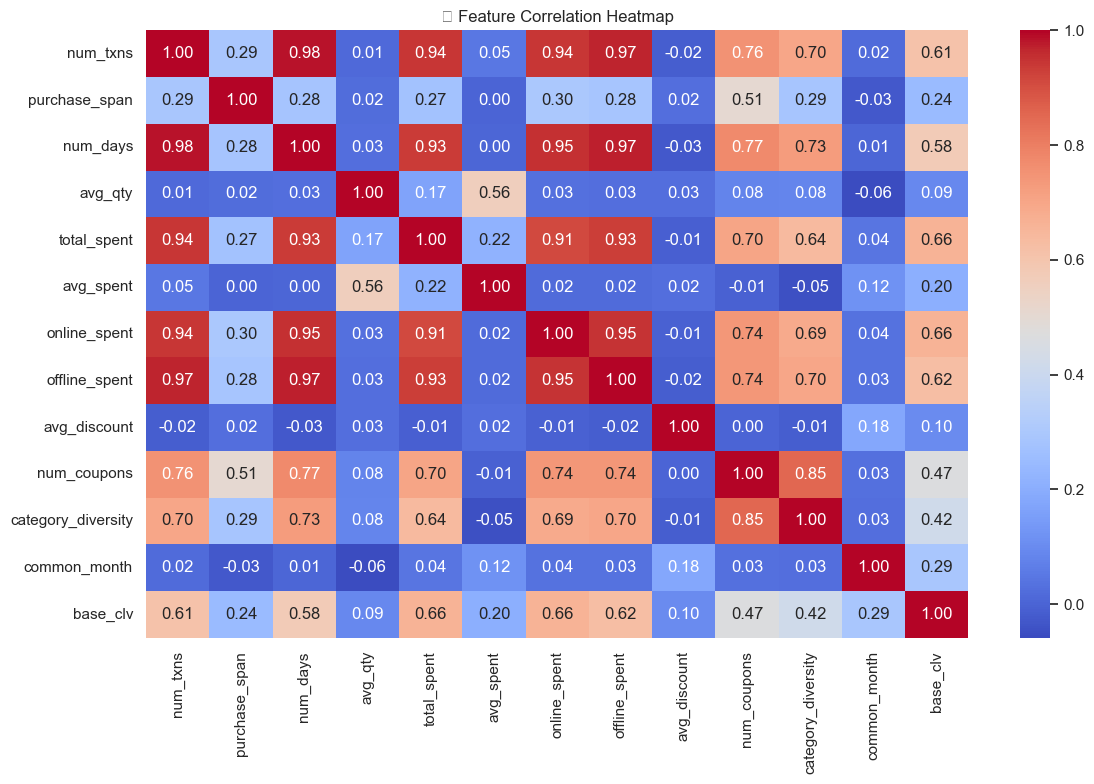

In [65]:
# Bucketing monetary and recency
features['spent_bucket'] = pd.qcut(features['total_spent'], 4, labels=['Low', 'Med', 'High', 'VIP'])
features['discount_bucket'] = pd.qcut(features['avg_discount'], 4, labels=['Low', 'Mid', 'High', 'Extreme'])

# Heatmap of correlations
plt.figure(figsize=(12, 8))
sns.heatmap(features.drop(columns=['CustomerID', 'spent_bucket', 'discount_bucket']).corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("📊 Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


##  10 Hypothesis Visualizations

### Hypothesis 1: Customers with higher tenure spend more.

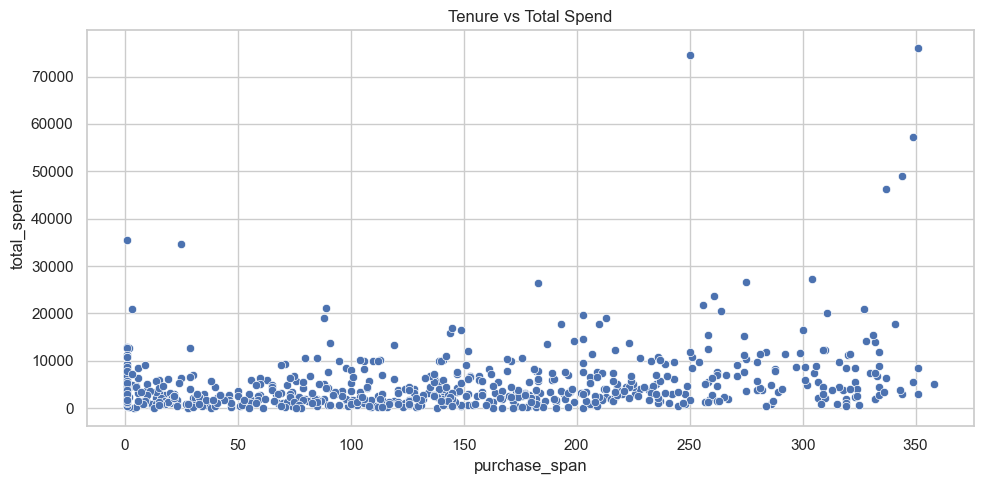

In [66]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=features, x='purchase_span', y='total_spent'); plt.title('Tenure vs Total Spend')
plt.tight_layout()
plt.show()


### Hypothesis 2: Online spenders have higher CLV than offline spenders.

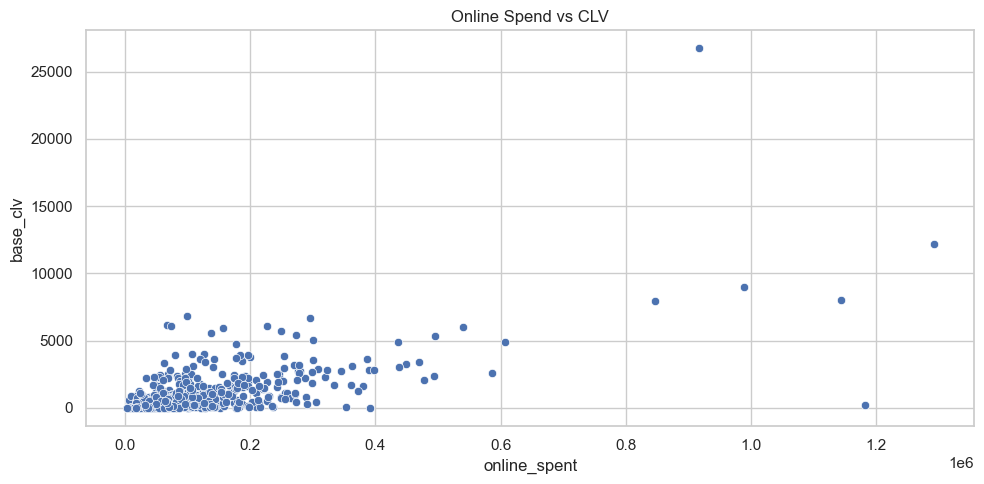

In [67]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=features, x='online_spent', y='base_clv'); plt.title('Online Spend vs CLV')
plt.tight_layout()
plt.show()


### Hypothesis 3: High-quantity purchases correlate with lower unit prices (bulk buying).

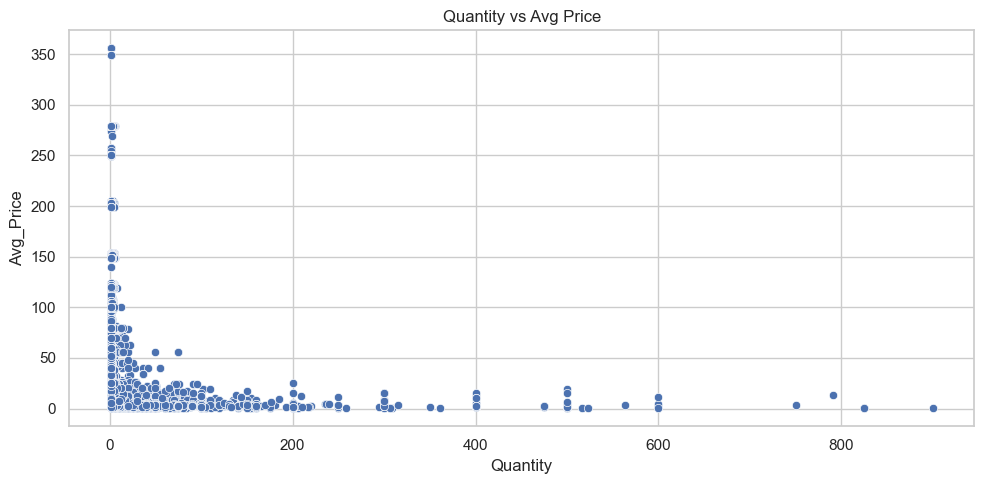

In [68]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Quantity', y='Avg_Price'); plt.title('Quantity vs Avg Price')
plt.tight_layout()
plt.show()


### Hypothesis 4: Repeat customers have increasing spend trend over months.

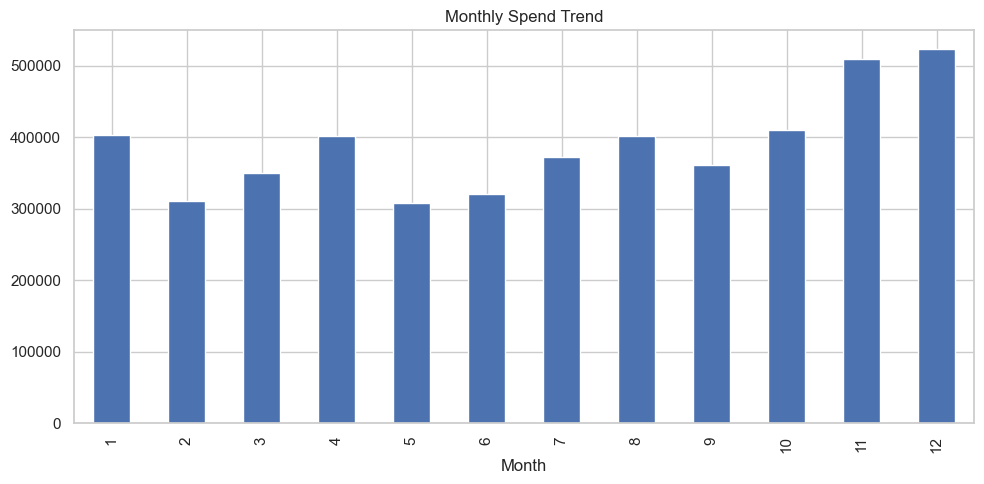

In [69]:
plt.figure(figsize=(10, 5))
monthly_spend = df.groupby('Month')['TotalPrice'].sum(); monthly_spend.plot(kind='bar'); plt.title('Monthly Spend Trend')
plt.tight_layout()
plt.show()


### Hypothesis 5: CLV is higher for customers who use coupons wisely.

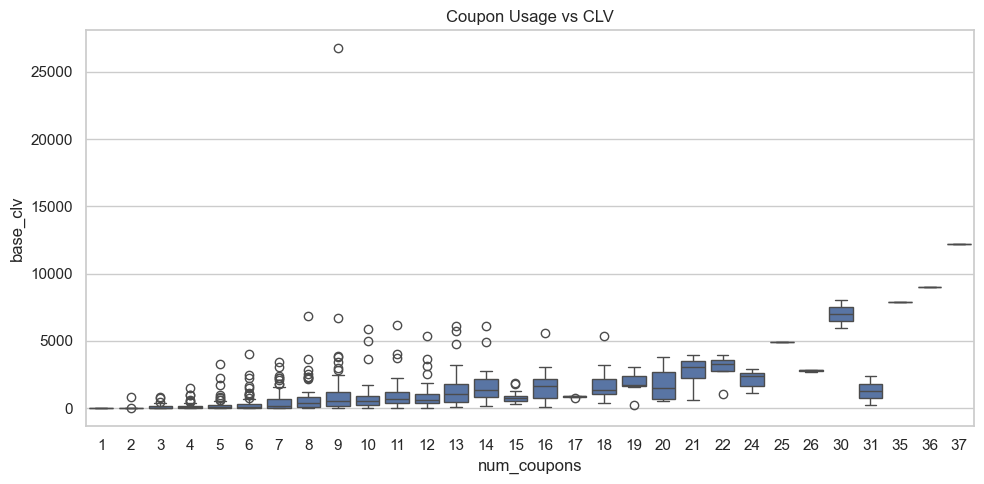

In [70]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=features, x='num_coupons', y='base_clv'); plt.title('Coupon Usage vs CLV')
plt.tight_layout()
plt.show()


### Hypothesis 6: Certain product categories contribute disproportionately to revenue.

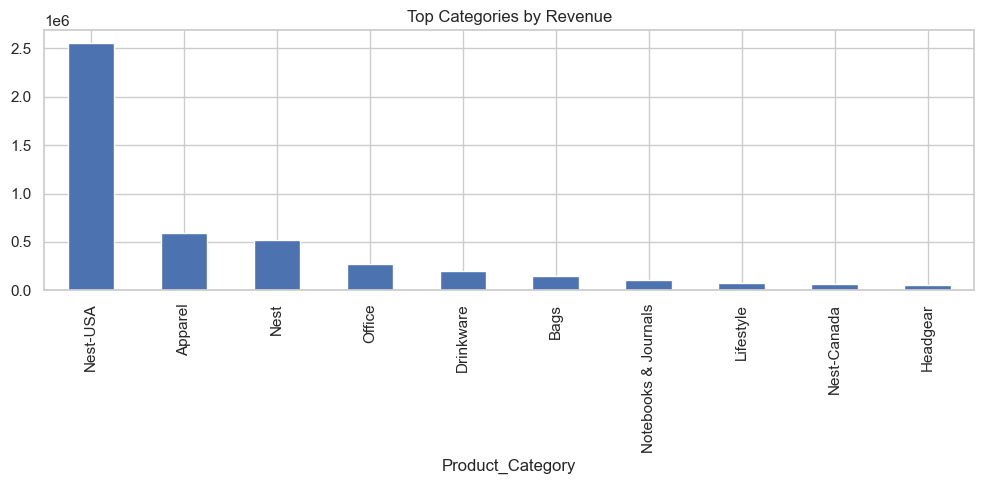

In [71]:
plt.figure(figsize=(10, 5))
top_categories = df.groupby('Product_Category')['TotalPrice'].sum().sort_values(ascending=False).head(10); top_categories.plot(kind='bar'); plt.title('Top Categories by Revenue')
plt.tight_layout()
plt.show()


### Hypothesis 7: Customers buying from multiple categories have higher CLV.

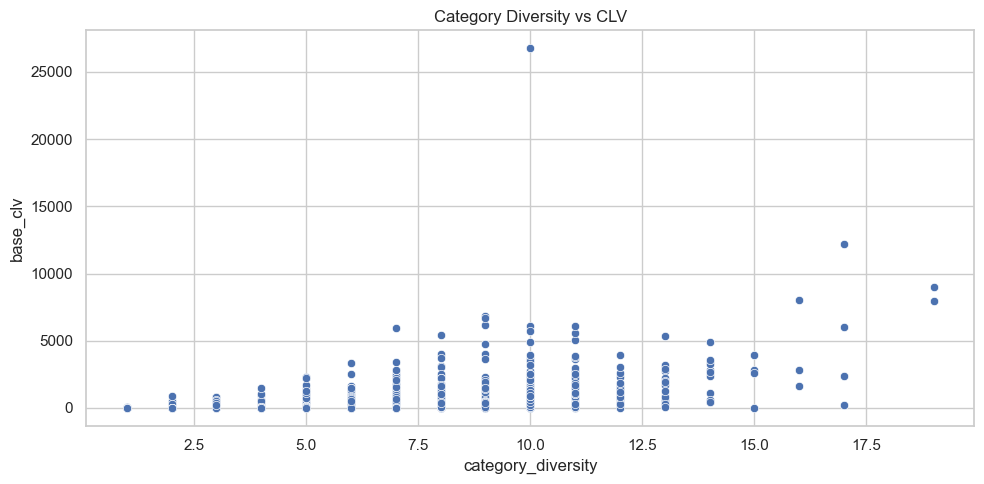

In [72]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=features, x='category_diversity', y='base_clv'); plt.title('Category Diversity vs CLV')
plt.tight_layout()
plt.show()


### Hypothesis 8: Coupon usage is seasonal and affects purchase behavior.

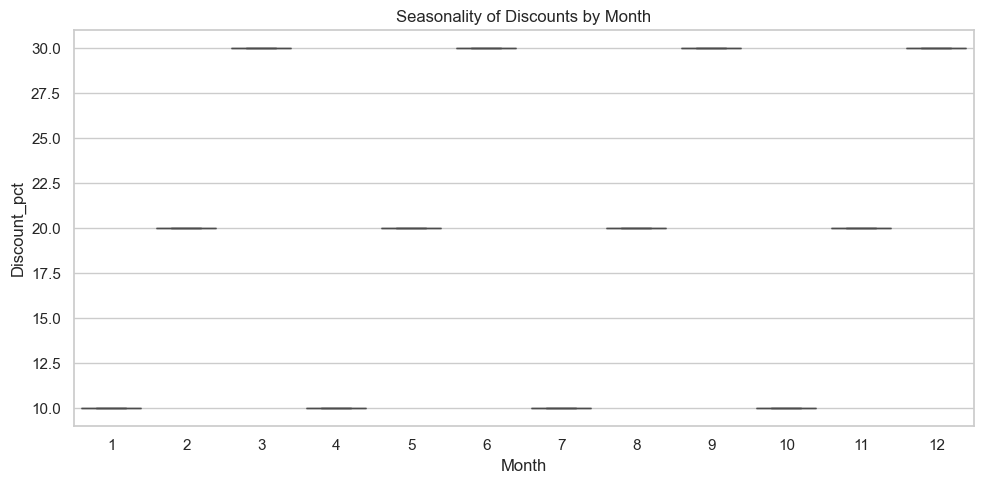

In [73]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Month', y='Discount_pct'); plt.title('Seasonality of Discounts by Month')
plt.tight_layout()
plt.show()


### Hypothesis 9: Short-tenure, high-spend customers may be VIPs or offer-hunters.

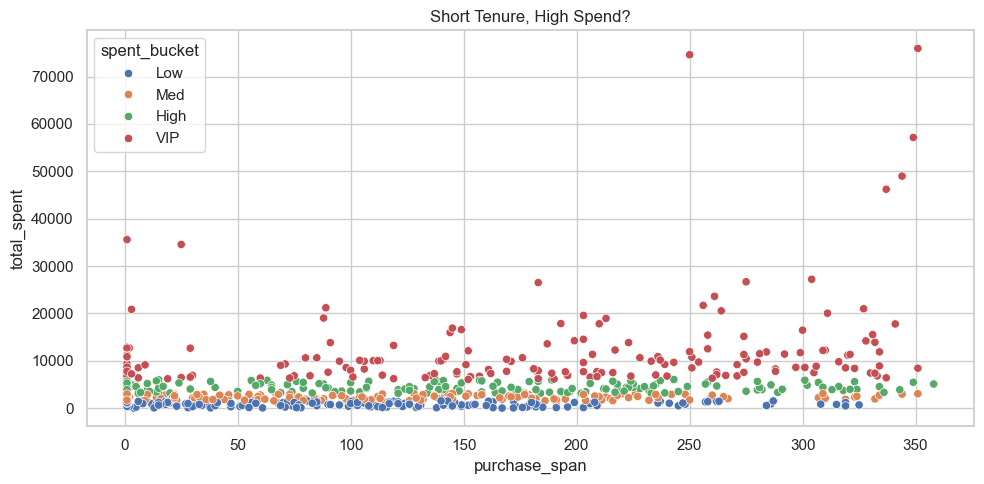

In [74]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=features, x='purchase_span', y='total_spent', hue='spent_bucket'); plt.title('Short Tenure, High Spend?')
plt.tight_layout()
plt.show()


### Hypothesis 10: Few customers generate most revenue (Pareto principle).

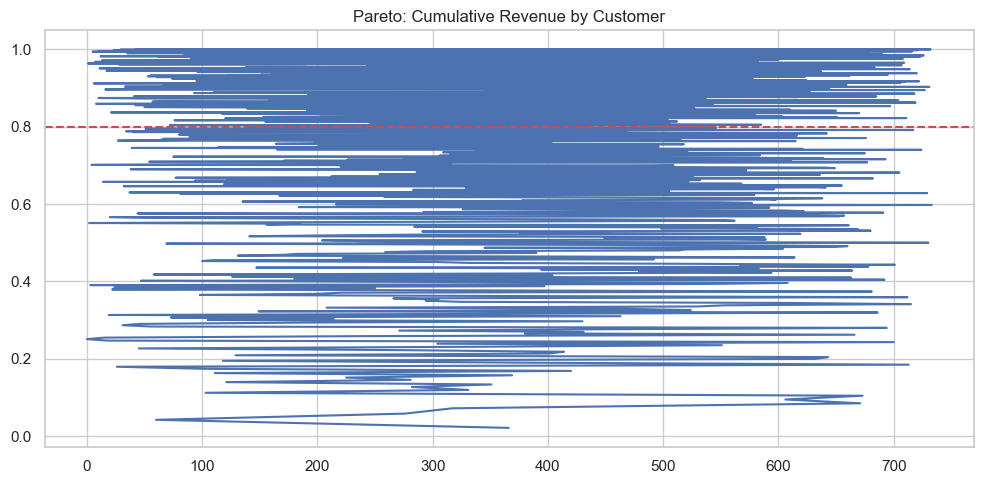

In [75]:
plt.figure(figsize=(10, 5))
rev_by_cust = features.sort_values('total_spent', ascending=False); rev_by_cust['cum_pct'] = rev_by_cust['total_spent'].cumsum() / rev_by_cust['total_spent'].sum(); rev_by_cust['cum_pct'].plot(); plt.axhline(0.8, color='r', linestyle='--'); plt.title('Pareto: Cumulative Revenue by Customer')
plt.tight_layout()
plt.show()


##  XGBoost Modeling with Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import shap

# Prepare features
X = features.drop(columns=['CustomerID', 'base_clv', 'spent_bucket', 'discount_bucket'])
y = features['base_clv']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model with tuning
params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1]
}

xgb = XGBRegressor(random_state=42)
grid = GridSearchCV(xgb, param_grid=params, cv=3, scoring='neg_root_mean_squared_error')
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

# Evaluate
y_pred = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE (sqrt method): {rmse:.2f}")
print(f"R²: {r2_score(y_test, y_pred):.2f}")


RMSE (sqrt method): 1297.80
R²: -0.39


##  SHAP Value Interpretation

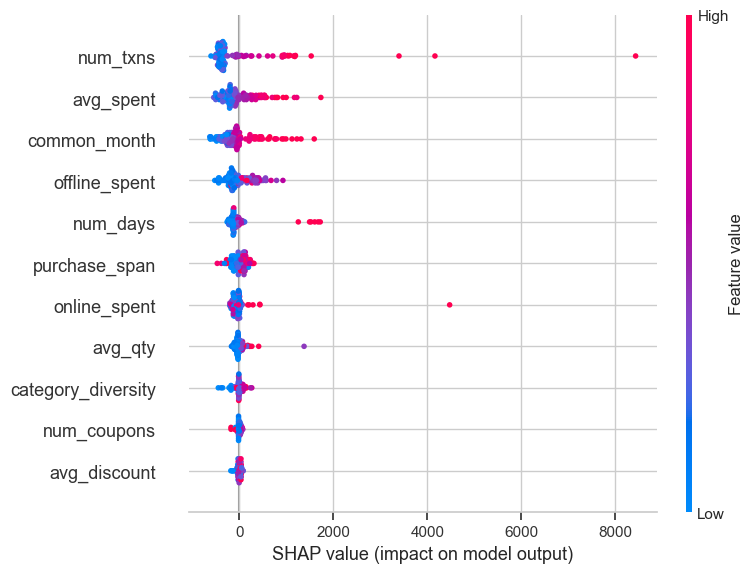

In [77]:
explainer = shap.Explainer(best_model, X_test)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)


##  Final Customer Segmentation

In [78]:

# Define the original training feature columns
feature_cols = ['num_txns', 'purchase_span', 'num_days', 'avg_qty',
                'total_spent', 'avg_spent', 'online_spent', 'offline_spent',
                'avg_discount', 'num_coupons', 'category_diversity', 'common_month']

# Predict only with those columns
features['predicted_clv'] = best_model.predict(features[feature_cols])

# Segment customers into 3 groups based on predicted CLV
features['segment'] = pd.qcut(features['predicted_clv'], q=3,
                               labels=['Low Value', 'Medium Value', 'High Value'])

# Show summary stats for each segment
seg_summary = features.groupby('segment')['predicted_clv'].agg(['count', 'mean', 'sum'])
print(seg_summary)

# Export final dataset
features.to_csv("final_customer_clv_segments.csv", index=False)


ValueError: feature_names mismatch: ['num_txns', 'purchase_span', 'num_days', 'avg_qty', 'avg_spent', 'online_spent', 'offline_spent', 'avg_discount', 'num_coupons', 'category_diversity', 'common_month'] ['num_txns', 'purchase_span', 'num_days', 'avg_qty', 'total_spent', 'avg_spent', 'online_spent', 'offline_spent', 'avg_discount', 'num_coupons', 'category_diversity', 'common_month']
training data did not have the following fields: total_spent